# 🏆 Bayesian Sports Analytics — Ligue 1

**Projet** : I.2 — Modèles hiérarchiques bayésiens pour prédire les résultats sportifs   
**Source des données** : [football-data.co.uk](https://www.football-data.co.uk/)
**Par ETHAN ARFI (SEUL)**
---

(Je tiens à préciser que le code a été mis au propre via Claude et qu'il m'a aidé a générer car étant seul )


In [1]:
#!pip install pymc3 arviz graphviz matplotlib seaborn pandas numpy

## 0. Installation & Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import pymc as pm
import pytensor.tensor as pt
import arviz as az

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Chargement des données Ligue 1

On utilise les fichiers CSV publics de [football-data.co.uk](https://www.football-data.co.uk/frenchm.php).

**Colonnes clés :**
- `HomeTeam`, `AwayTeam` : équipes
- `FTHG`, `FTAG` : buts à mi-temps et fin de match (Full Time Home/Away Goals)
- `FTR` : résultat (H = domicile, D = nul, A = extérieur)
- `B365H`, `B365D`, `B365A` : cotes Bet365 (domicile / nul / extérieur)
- `PSH`, `PSD`, `PSA` : cotes Pinnacle (bookmaker de référence, marge ≈ 2%)

In [3]:
# Sources : https://www.football-data.co.uk/frenchm.php
URLS = {
    "2022-23": "https://www.football-data.co.uk/mmz4281/2223/F1.csv",
    "2023-24": "https://www.football-data.co.uk/mmz4281/2324/F1.csv",
}

dfs = []
for season, url in URLS.items():
    try:
        df_tmp = pd.read_csv(url)
        df_tmp['Season'] = season
        dfs.append(df_tmp)
        print(f"✓ {season} : {len(df_tmp)} matchs chargés")
    except Exception as e:
        print(f"✗ {season} : {e}")

raw = pd.concat(dfs, ignore_index=True)

# Colonnes essentielles
COLS_BASE = ['Season', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']
COLS_ODDS = ['B365H', 'B365D', 'B365A', 'PSH', 'PSD', 'PSA']
available_odds = [c for c in COLS_ODDS if c in raw.columns]

df = raw[COLS_BASE + available_odds].dropna(subset=['FTHG', 'FTAG']).copy()
df['FTHG'] = df['FTHG'].astype(int)
df['FTAG'] = df['FTAG'].astype(int)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print(f"\n📊 Total matchs   : {len(df)}")
print(f"📅 Période        : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"🏟️  Équipes uniques : {df['HomeTeam'].nunique()}")
print(f"🎲 Cotes disponibles : {available_odds}")
df.head(5)

✓ 2022-23 : 380 matchs chargés
✓ 2023-24 : 306 matchs chargés

📊 Total matchs   : 686
📅 Période        : 2022-08-05 → 2024-05-19
🏟️  Équipes uniques : 22
🎲 Cotes disponibles : ['B365H', 'B365D', 'B365A', 'PSH', 'PSD', 'PSA']


,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A,PSH,PSD,PSA
0,2022-23,2022-08-05,Lyon,Ajaccio,2,1,H,1.33,5.25,8.50,1.33,5.53,10.75
1,2022-23,2022-08-06,Strasbourg,Monaco,1,2,A,2.62,3.25,2.75,2.64,3.40,2.86
2,2022-23,2022-08-06,Clermont,Paris SG,0,5,A,9.50,6.50,1.25,9.88,6.81,1.28
3,2022-23,2022-08-07,Rennes,Lorient,0,1,A,1.36,5.25,8.50,1.36,5.56,9.19
4,2022-23,2022-08-07,Montpellier,Troyes,3,2,H,2.20,3.50,3.30,2.21,3.53,3.49


## 2. Exploration des données (EDA)

### Distribution des buts — Test de l'hypothèse Poisson

Le modèle de Maher (1982) et Baio & Blangiardo (2010) supposent que les buts suivent
une loi de Poisson. Vérifions graphiquement cette hypothèse.

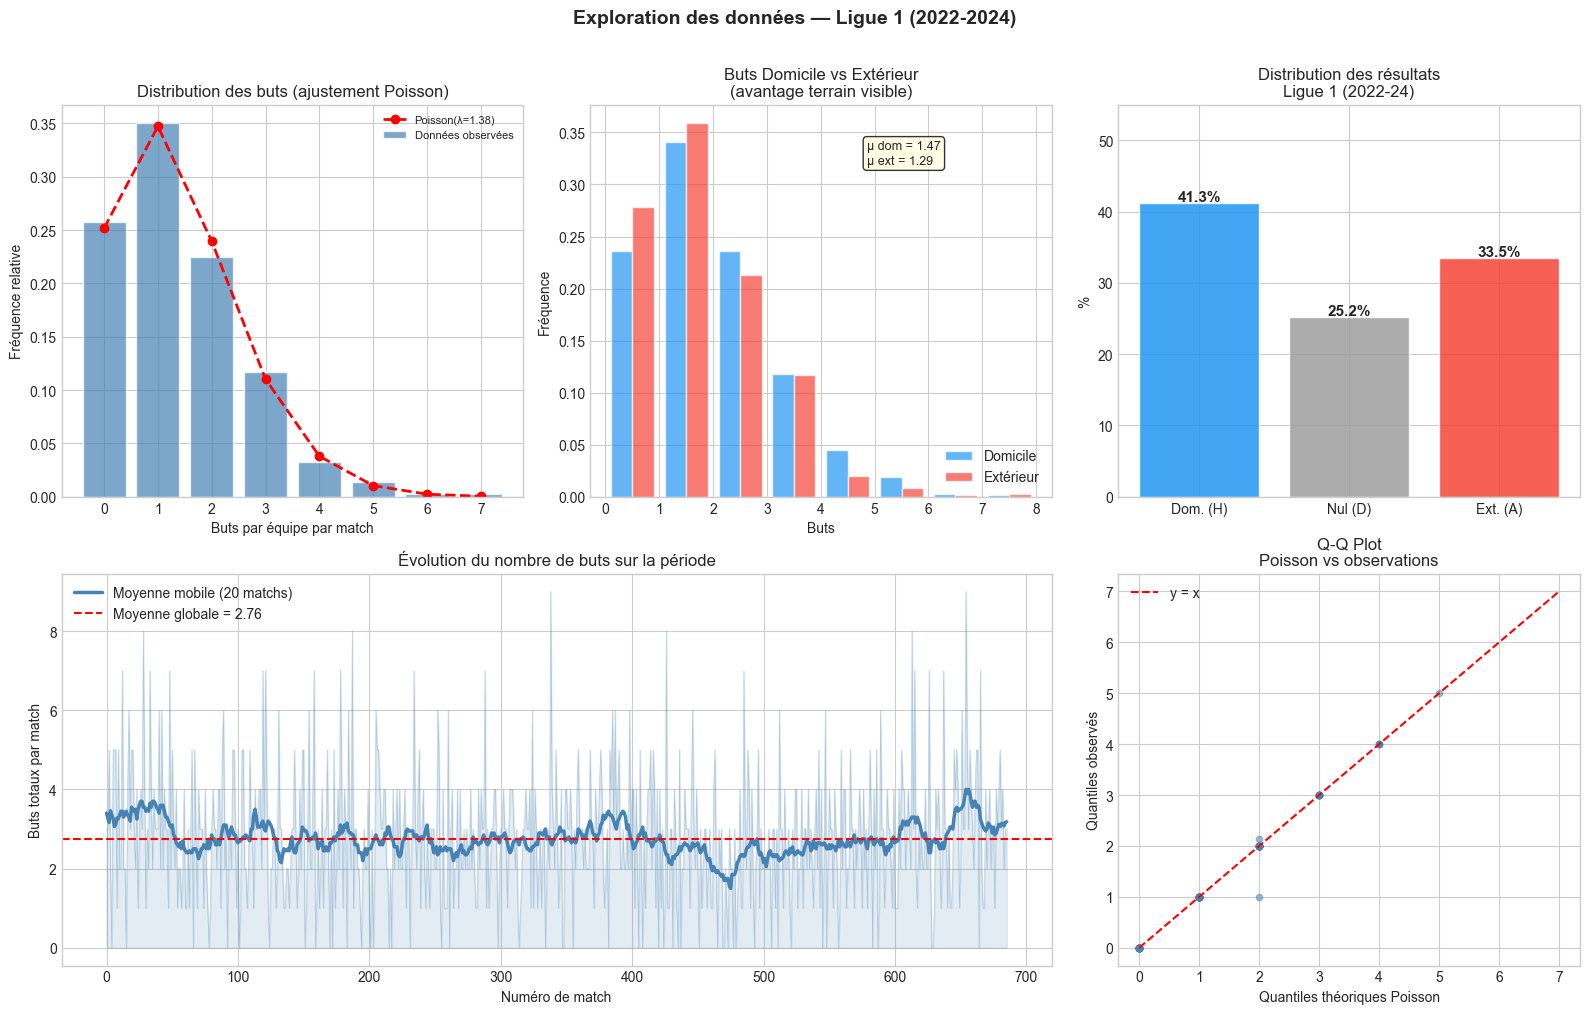


📈 Statistiques descriptives
Buts marqués par match (dom.) : 1.471 ± 1.249
Buts marqués par match (ext.) : 1.289 ± 1.158
Avantage terrain moyen        : 0.182 but
% Victoires domicile          : 41.3%
% Nuls                        : 25.2%
% Victoires extérieur         : 33.5%


In [4]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

# ── 1. Distribution des buts avec ajustement Poisson 
ax1 = fig.add_subplot(gs[0, 0])
goals_all = pd.concat([df['FTHG'], df['FTAG']])
lambda_fit = goals_all.mean()
counts = goals_all.value_counts().sort_index()
x = np.arange(0, int(goals_all.max()) + 1)

ax1.bar(counts.index, counts.values / len(goals_all), color='steelblue', alpha=0.7,
        label='Données observées', edgecolor='white')
ax1.plot(x, stats.poisson.pmf(x, lambda_fit), 'ro--', markersize=6,
         label=f'Poisson(λ={lambda_fit:.2f})', linewidth=2)
ax1.set_xlabel('Buts par équipe par match')
ax1.set_ylabel('Fréquence relative')
ax1.set_title('Distribution des buts (ajustement Poisson)')
ax1.legend(fontsize=8)

# ── 2. Buts domicile vs extérieur 
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist([df['FTHG'], df['FTAG']], bins=range(0, 9), density=True,
         label=['Domicile', 'Extérieur'], color=['#2196F3', '#F44336'],
         alpha=0.7, edgecolor='white')
ax2.set_xlabel('Buts')
ax2.set_ylabel('Fréquence')
ax2.set_title('Buts Domicile vs Extérieur\n(avantage terrain visible)')
ax2.legend()
ax2.text(0.6, 0.85,
         f"μ dom = {df['FTHG'].mean():.2f}\nμ ext = {df['FTAG'].mean():.2f}",
         transform=ax2.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── 3. Distribution des résultats 
ax3 = fig.add_subplot(gs[0, 2])
results_pct = df['FTR'].value_counts(normalize=True)[['H', 'D', 'A']]
bars = ax3.bar(['Dom. (H)', 'Nul (D)', 'Ext. (A)'],
               results_pct.values * 100,
               color=['#2196F3', '#9E9E9E', '#F44336'], alpha=0.85, edgecolor='white')
ax3.set_ylabel('%')
ax3.set_title('Distribution des résultats\nLigue 1 (2022-24)')
for bar, pct in zip(bars, results_pct.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{pct*100:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax3.set_ylim(0, 55)

# ── 4. Buts par journée
ax4 = fig.add_subplot(gs[1, :2])
df_sorted = df.sort_values('Date').copy()
df_sorted['total_goals'] = df_sorted['FTHG'] + df_sorted['FTAG']
df_sorted['n'] = range(len(df_sorted))
rolling = df_sorted['total_goals'].rolling(20, center=True, min_periods=5).mean()
ax4.fill_between(df_sorted['n'], df_sorted['total_goals'], alpha=0.15, color='steelblue')
ax4.plot(df_sorted['n'], df_sorted['total_goals'], alpha=0.3, color='steelblue', linewidth=0.5)
ax4.plot(df_sorted['n'], rolling, color='steelblue', linewidth=2.5, label='Moyenne mobile (20 matchs)')
ax4.axhline(df_sorted['total_goals'].mean(), color='red', linestyle='--',
            label=f"Moyenne globale = {df_sorted['total_goals'].mean():.2f}")
ax4.set_xlabel('Numéro de match')
ax4.set_ylabel('Buts totaux par match')
ax4.set_title('Évolution du nombre de buts sur la période')
ax4.legend()

# ── 5. Test de Poisson
ax5 = fig.add_subplot(gs[1, 2])
obs_quantiles = np.quantile(goals_all, np.linspace(0.01, 0.99, 100))
theoretical_quantiles = stats.poisson.ppf(np.linspace(0.01, 0.99, 100), lambda_fit)
ax5.scatter(theoretical_quantiles, obs_quantiles, alpha=0.5, s=20, color='steelblue')
ax5.plot([0, 7], [0, 7], 'r--', label='y = x')
ax5.set_xlabel('Quantiles théoriques Poisson')
ax5.set_ylabel('Quantiles observés')
ax5.set_title('Q-Q Plot\nPoisson vs observations')
ax5.legend()

plt.suptitle('Exploration des données — Ligue 1 (2022-2024)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Stats résumées
print("\n📈 Statistiques descriptives")
print("=" * 40)
print(f"Buts marqués par match (dom.) : {df['FTHG'].mean():.3f} ± {df['FTHG'].std():.3f}")
print(f"Buts marqués par match (ext.) : {df['FTAG'].mean():.3f} ± {df['FTAG'].std():.3f}")
print(f"Avantage terrain moyen        : {(df['FTHG'].mean() - df['FTAG'].mean()):.3f} but")
print(f"% Victoires domicile          : {(df['FTR']=='H').mean()*100:.1f}%")
print(f"% Nuls                        : {(df['FTR']=='D').mean()*100:.1f}%")
print(f"% Victoires extérieur         : {(df['FTR']=='A').mean()*100:.1f}%")

## 3. Modèle bayésien hiérarchique de Poisson

### 3.1 Préparation des données

On utilise la saison **2023-24** pour estimer les forces actuelles des équipes.

In [5]:
# ── Filtrer sur la saison 2023-24
df_model = df[df['Season'] == '2023-24'].copy().reset_index(drop=True)

# Nommer les équipe → Ordre alphabétique
teams = sorted(df_model['HomeTeam'].unique().tolist())
team_to_idx = {t: i for i, t in enumerate(teams)}
n_teams = len(teams)
n_games  = len(df_model)

# Indices numpy
home_idx = df_model['HomeTeam'].map(team_to_idx).values.astype(int)
away_idx = df_model['AwayTeam'].map(team_to_idx).values.astype(int)
y_home   = df_model['FTHG'].values.astype(int)
y_away   = df_model['FTAG'].values.astype(int)

coords = {
    "team" : teams,
    "match": np.arange(n_games),
}

print(f"🏆 Saison : 2023-24")
print(f"⚽ Matchs : {n_games}")
print(f"🏟️  Équipes ({n_teams}) :")
for i, t in enumerate(teams):
    print(f"   {i:2d}. {t}")

🏆 Saison : 2023-24
⚽ Matchs : 306
🏟️  Équipes (18) :
    0. Brest
    1. Clermont
    2. Le Havre
    3. Lens
    4. Lille
    5. Lorient
    6. Lyon
    7. Marseille
    8. Metz
    9. Monaco
   10. Montpellier
   11. Nantes
   12. Nice
   13. Paris SG
   14. Reims
   15. Rennes
   16. Strasbourg
   17. Toulouse


### 3.2 Spécification du modèle PyMC

In [6]:

with pm.Model(coords=coords) as model_baio:

    # Contrôlent la dispersion des forces entre équipes
    sigma_att = pm.HalfNormal("sigma_att", sigma=1.0)
    sigma_def = pm.HalfNormal("sigma_def", sigma=1.0)

  
    # Positif → jouer à domicile augmente les buts marqués
    home_adv = pm.Normal("home_adv", mu=0.0, sigma=1.0)

    # EFFETS PAR ÉQUIPE (contrainte somme nulle)
    # ZeroSumNormal garantit sum_t att_t = 0
    att  = pm.ZeroSumNormal("att",  sigma=sigma_att, dims="team")
    def_ = pm.ZeroSumNormal("def_", sigma=sigma_def, dims="team")

    # INTENSITÉS DE SCORE (log-linéaire)
    log_theta_home = home_adv + att[home_idx] + def_[away_idx]
    log_theta_away =            att[away_idx] + def_[home_idx]

    theta_home = pm.Deterministic("theta_home", pm.math.exp(log_theta_home), dims="match")
    theta_away = pm.Deterministic("theta_away", pm.math.exp(log_theta_away), dims="match")

    # VRAISEMBLANCE
    goals_home = pm.Poisson("goals_home", mu=theta_home, observed=y_home, dims="match")
    goals_away = pm.Poisson("goals_away", mu=theta_away, observed=y_away, dims="match")

# Visualisation du graphe causal (DAG)
print("Modèle défini ✓")
print(f"Variables libres : {[v.name for v in model_baio.free_RVs]}")
print(f"Variables déterministes : {[v.name for v in model_baio.deterministics]}")

Modèle défini ✓
Variables libres : ['sigma_att', 'sigma_def', 'home_adv', 'att', 'def_']
Variables déterministes : ['theta_home', 'theta_away']


### 3.3 Prior Predictive Check

Avant l'inférence, on vérifie que nos priors génèrent des données plausibles
(i.e. pas de matchs avec 50 buts).

In [7]:
with model_baio:
    prior_pc = pm.sample_prior_predictive(samples=500, random_seed=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes,
                           ['goals_home', 'goals_away'],
                           ['Buts Domicile', 'Buts Extérieur']):
    sim_goals = prior_pc.prior_predictive[col].values.flatten()
    # Tronquer pour la lisibilité
    sim_goals_trunc = sim_goals[sim_goals <= 15]
    ax.hist(sim_goals_trunc, bins=range(0, 16), density=True,
            alpha=0.7, color='steelblue', edgecolor='white', label='Simulation a priori')
    obs = y_home if label == 'Buts Domicile' else y_away
    ax.hist(obs, bins=range(0, 10), density=True,
            alpha=0.5, color='red', edgecolor='white', label='Données réelles')
    ax.set_xlabel('Buts')
    ax.set_ylabel('Densité')
    ax.set_title(f'Prior Predictive — {label}')
    ax.legend()
    ax.set_xlim(0, 12)

plt.suptitle('Prior Predictive Check\n(les priors doivent englober les données réelles)', fontsize=12)
plt.tight_layout()
plt.show()


You can find the C code in this temporary file: /var/folders/6z/0ysc19cs4298bfxt_gl6xcdc0000gn/T/pytensor_compilation_error_71iyaaso


CompileError: Compilation failed (return status=1):
/usr/bin/clang++ -dynamiclib -g -O3 -fno-math-errno -Wno-unused-label -Wno-unused-variable -Wno-write-strings -Wno-c++11-narrowing -fno-exceptions -fno-unwind-tables -fno-asynchronous-unwind-tables -DNPY_NO_DEPRECATED_API=NPY_1_7_API_VERSION -fPIC -undefined dynamic_lookup -ld64 -I/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/include -I/Library/Frameworks/Python.framework/Versions/3.12/include/python3.12 -I/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pytensor/link/c/c_code -L/Library/Frameworks/Python.framework/Versions/3.12/lib -fvisibility=hidden -o /Users/arfi/.pytensor/compiledir_macOS-26.2-arm64-arm-64bit-arm-3.12.2-64/tmpoortiy5_/mb297ea4414b50956b92a6c2ff7dba50af5458a56ec7f27e72c6a8728651ac04b.so /Users/arfi/.pytensor/compiledir_macOS-26.2-arm64-arm-64bit-arm-3.12.2-64/tmpoortiy5_/mod.cpp
/Users/arfi/.pytensor/compiledir_macOS-26.2-arm64-arm-64bit-

### 3.4 Inférence MCMC 

On utilise l'algorithme NUTS de PyMC.

- `draws = 2000` : 2000 échantillons par chaîne
- `tune = 1000` : 1000 étapes d'adaptation (écartées)
- `chains = 4` : 4 chaînes pour diagnostiquer la convergence
- `target_accept = 0.9` : taux d'acceptation cible

In [ ]:
with model_baio:
    idata = pm.sample(
        draws        = 2000,
        tune         = 1000,
        chains       = 4,
        target_accept= 0.9,
        random_seed  = 42,
        progressbar  = True,
    )
    # Distribution prédictive postérieure sur les données d'entraînement
    pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=42)

print("\n✓ Inférence terminée")
az.summary(idata, var_names=["home_adv", "sigma_att", "sigma_def"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_att, sigma_def, home_adv, att, def_]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 124 seconds.
Sampling: [goals_away, goals_home]



✓ Inférence terminée


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
home_adv,0.319,0.048,0.226,0.408,0.000,0.001,10568.0,6030.0,1.0
sigma_att,0.274,0.067,0.156,0.399,0.001,0.001,6299.0,5598.0,1.0
sigma_def,0.193,0.062,0.085,0.313,0.001,0.001,2319.0,1567.0,1.0


## 4. Diagnostics et analyse des postérieurs

### 4.1 Convergence des chaînes MCMC

> 🟢 Verfier que R converge vers 1 max, sinon modifier les parametres avant d'avancer

In [ ]:
# Résumé statistique des paramètres globaux
summary_global = az.summary(idata, var_names=["home_adv", "sigma_att", "sigma_def"],
                             round_to=4)
print("Paramètres globaux :")
print(summary_global)
print()

# Vérification des R-hat
rhat = az.rhat(idata)
rhat_max = float(max(
    rhat["home_adv"].values.max(),
    rhat["sigma_att"].values.max(),
    rhat["sigma_def"].values.max(),
    rhat["att"].values.max(),
    rhat["def_"].values.max()
))
print(f"R̂ maximum (tous paramètres) : {rhat_max:.4f}")
if rhat_max < 1.01:
    print("✅ Convergence excellente (R̂ < 1.01)")
elif rhat_max < 1.05:
    print("⚠️  Convergence acceptable (R̂ < 1.05)")
else:
    print("❌ Problème de convergence — augmenter tune ou target_accept")

Paramètres globaux :
             mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd    ess_bulk  \
home_adv   0.3192  0.0485  0.2264   0.4084     0.0005   0.0006  10567.5179   
sigma_att  0.2735  0.0673  0.1560   0.3986     0.0008   0.0008   6298.8110   
sigma_def  0.1928  0.0620  0.0851   0.3131     0.0012   0.0010   2318.9130   

            ess_tail   r_hat  
home_adv   6029.7284  1.0012  
sigma_att  5597.9317  1.0004  
sigma_def  1567.3598  1.0007  

R̂ maximum (tous paramètres) : 1.0018
✅ Convergence excellente (R̂ < 1.01)


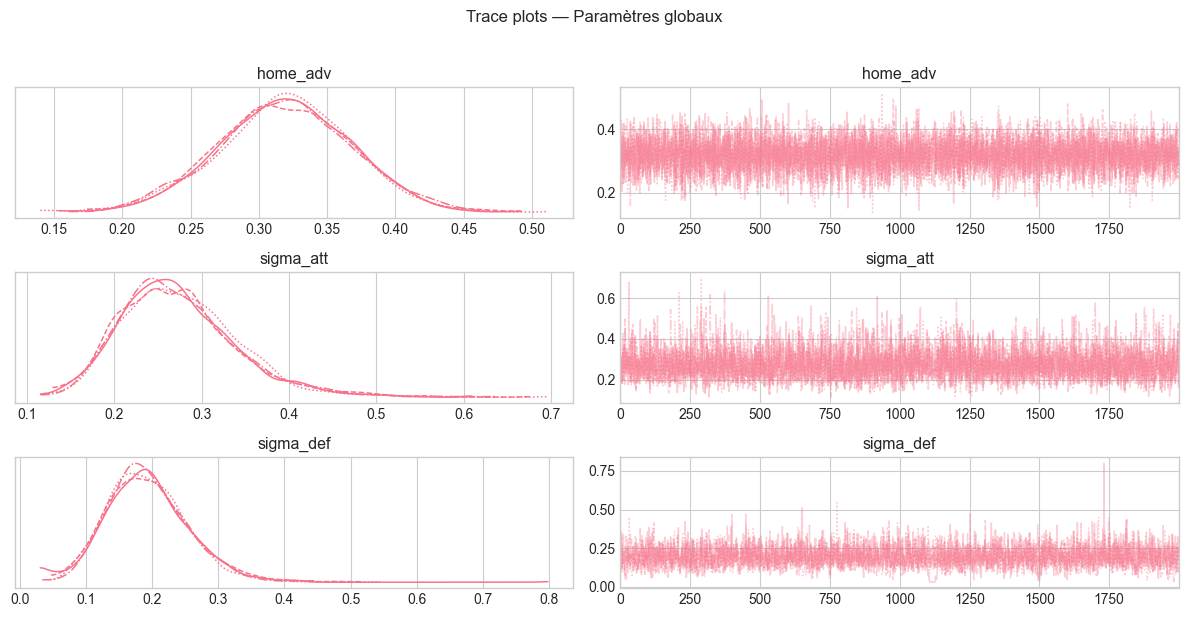

In [ ]:
# Trace plots
az.plot_trace(idata, var_names=["home_adv", "sigma_att", "sigma_def"],
              compact=True, figsize=(12, 6))
plt.suptitle("Trace plots — Paramètres globaux", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Le modèle reproduit-il la distribution observée des buts ?

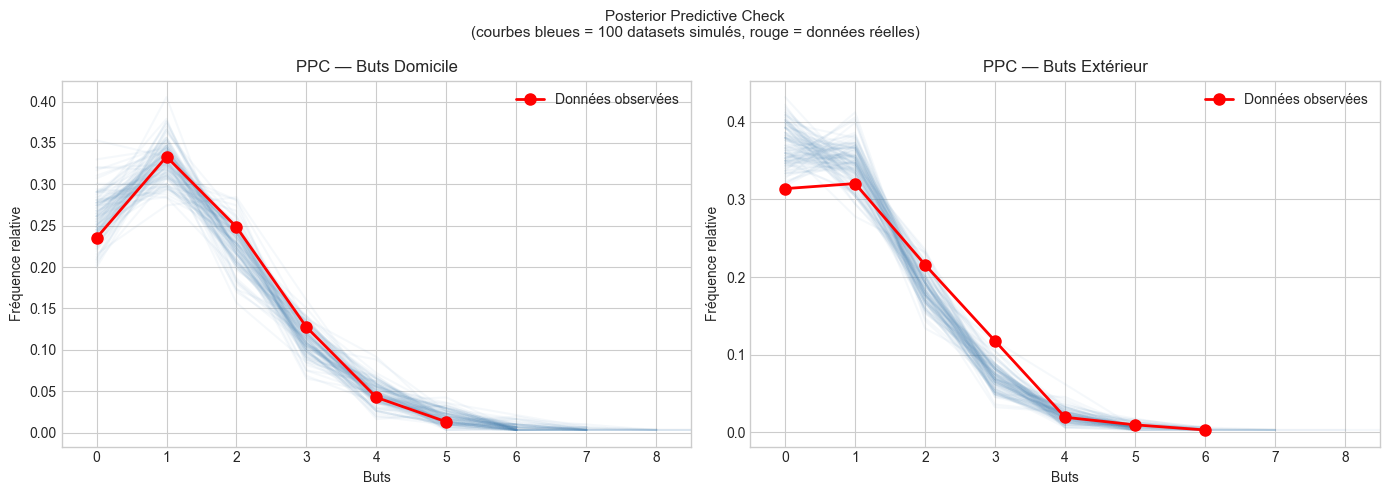

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, obs, label in zip(
    axes,
    ['goals_home', 'goals_away'],
    [y_home, y_away],
    ['Domicile', 'Extérieur']
):
    ppc = idata.posterior_predictive[col].values
    # 100 simulations aléatoires
    for i in range(100):
        chain = np.random.randint(4)
        draw  = np.random.randint(2000)
        sim   = ppc[chain, draw]
        vals, cnts = np.unique(sim, return_counts=True)
        ax.plot(vals, cnts / len(sim), color='steelblue', alpha=0.05)

    # Données observées
    vals_obs, cnts_obs = np.unique(obs, return_counts=True)
    ax.plot(vals_obs, cnts_obs / len(obs), 'ro-', markersize=8,
            linewidth=2, label='Données observées', zorder=10)

    ax.set_xlabel('Buts')
    ax.set_ylabel('Fréquence relative')
    ax.set_title(f'PPC — Buts {label}')
    ax.set_xlim(-0.5, 8.5)
    ax.legend()

plt.suptitle('Posterior Predictive Check\n'
             '(courbes bleues = 100 datasets simulés, rouge = données réelles)',
             fontsize=11)
plt.tight_layout()
plt.show()

### 4.3 Forces d'attaque et défense par équipe

On extrait les moyennes et intervalles de crédibilité à 94% (HDI).

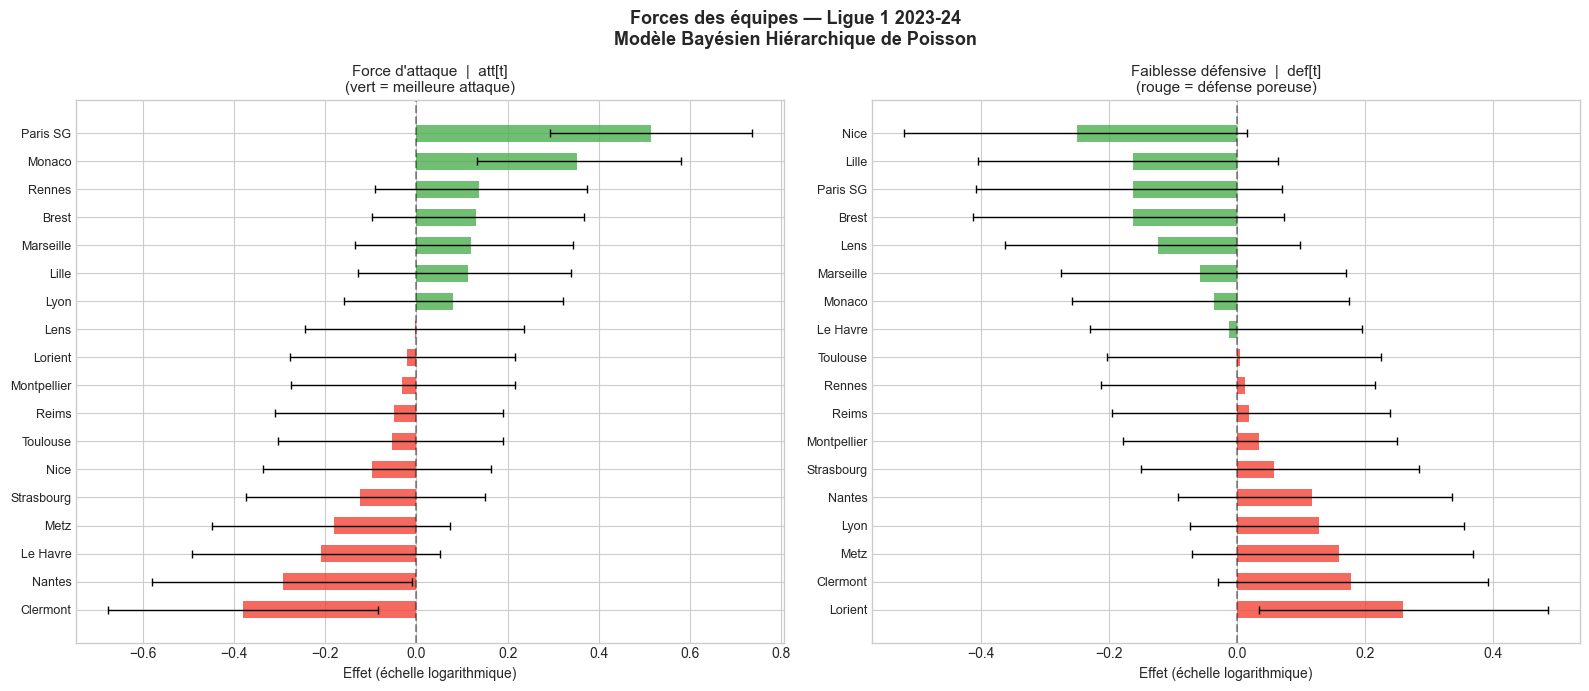

In [ ]:
# Moyennes postérieures
att_post  = idata.posterior["att"].values.reshape(-1, n_teams)
def_post  = idata.posterior["def_"].values.reshape(-1, n_teams)
att_mean  = att_post.mean(axis=0)
def_mean  = def_post.mean(axis=0)

# HDI 94%
att_hdi = az.hdi(idata.posterior["att"], hdi_prob=0.94)["att"].values
def_hdi = az.hdi(idata.posterior["def_"], hdi_prob=0.94)["def_"].values

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Attaque 
order_att = np.argsort(att_mean)
y_pos     = np.arange(n_teams)

colors_att = ['#4CAF50' if att_mean[i] > 0 else '#F44336' for i in order_att]
axes[0].barh(y_pos, att_mean[order_att], color=colors_att, alpha=0.8, height=0.6)
axes[0].errorbar(
    att_mean[order_att], y_pos,
    xerr=[att_mean[order_att] - att_hdi[order_att, 0],
          att_hdi[order_att, 1] - att_mean[order_att]],
    fmt='none', color='black', capsize=3, linewidth=1
)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([teams[i] for i in order_att], fontsize=9)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.4)
axes[0].set_title("Force d'attaque  |  att[t]\n(vert = meilleure attaque)", fontsize=11)
axes[0].set_xlabel("Effet (échelle logarithmique)")

# ── Défense 
order_def = np.argsort(def_mean)[::-1]   # du plus faible au plus fort (défense)
colors_def = ['#F44336' if def_mean[i] > 0 else '#4CAF50' for i in order_def]
axes[1].barh(y_pos, def_mean[order_def], color=colors_def, alpha=0.8, height=0.6)
axes[1].errorbar(
    def_mean[order_def], y_pos,
    xerr=[def_mean[order_def] - def_hdi[order_def, 0],
          def_hdi[order_def, 1] - def_mean[order_def]],
    fmt='none', color='black', capsize=3, linewidth=1
)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([teams[i] for i in order_def], fontsize=9)
axes[1].axvline(0, color='black', linestyle='--', alpha=0.4)
axes[1].set_title("Faiblesse défensive  |  def[t]\n(rouge = défense poreuse)", fontsize=11)
axes[1].set_xlabel("Effet (échelle logarithmique)")

plt.suptitle("Forces des équipes — Ligue 1 2023-24\nModèle Bayésien Hiérarchique de Poisson",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

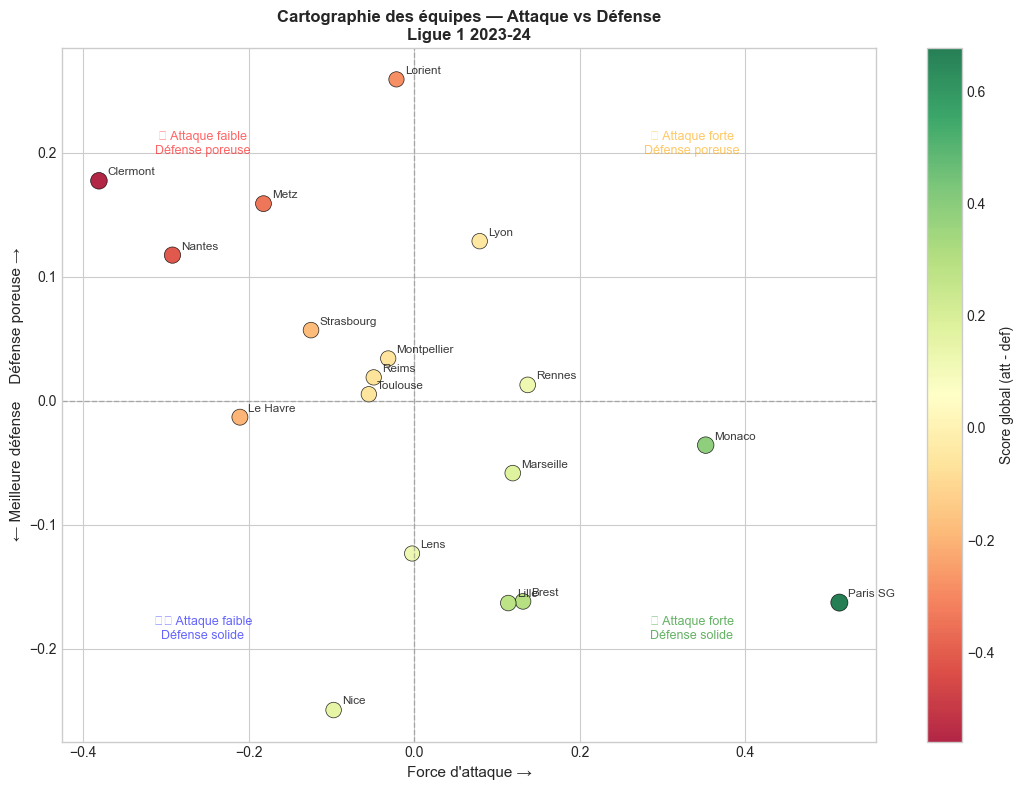

In [ ]:
# Diagramme attaque vs défense (quadrant)
fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(att_mean, def_mean,
                     s=[120 + 60 * abs(a) for a in att_mean],
                     c=att_mean - def_mean,   # score global = att - def
                     cmap='RdYlGn', alpha=0.85, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, ax=ax, label='Score global (att - def)')

for i, team in enumerate(teams):
    ax.annotate(team, (att_mean[i], def_mean[i]),
                textcoords="offset points", xytext=(6, 4),
                fontsize=8.5, alpha=0.9)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Labels des quadrants
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[1] * 0.6, ylim[0] * 0.7, "✅ Attaque forte\nDéfense solide",
        fontsize=9, color='green', alpha=0.6, ha='center')
ax.text(xlim[0] * 0.6, ylim[1] * 0.7, "❌ Attaque faible\nDéfense poreuse",
        fontsize=9, color='red', alpha=0.6, ha='center')
ax.text(xlim[1] * 0.6, ylim[1] * 0.7, "⚡ Attaque forte\nDéfense poreuse",
        fontsize=9, color='orange', alpha=0.6, ha='center')
ax.text(xlim[0] * 0.6, ylim[0] * 0.7, "🛡️ Attaque faible\nDéfense solide",
        fontsize=9, color='blue', alpha=0.6, ha='center')

ax.set_xlabel("Force d'attaque →", fontsize=11)
ax.set_ylabel("← Meilleure défense    Défense poreuse →", fontsize=11)
ax.set_title("Cartographie des équipes — Attaque vs Défense\nLigue 1 2023-24",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Prédiction de nouveaux matchs

### 5.1 Distribution prédictive postérieure

Pour prédire un match $h$ vs $a$, on intègre sur l'incertitude complète des paramètres :

$$P(\hat{y}_{h}, \hat{y}_{a} \mid y_{\text{obs}}) = \int P(\hat{y}_{h}, \hat{y}_{a} \mid \theta) \, P(\theta \mid y_{\text{obs}}) \, d\theta$$

En pratique, on échantillonne $\theta^{(s)}$ depuis le postérieur MCMC, puis on simule des buts.

In [ ]:
def predict_match(home_team, away_team, idata, teams, team_to_idx,
                  n_samples=8000, max_goals=9):
    """Prédit la distribution des scores et les probabilités de résultat pour un match donné."""
    h = team_to_idx[home_team]
    a = team_to_idx[away_team]

    # Extraire les échantillons postérieurs des paramètres
    post = idata.posterior
    att_s = post["att"].values.reshape(-1, len(teams))
    def_s = post["def_"].values.reshape(-1, len(teams))
    ha_s  = post["home_adv"].values.flatten()

    # Sélection aléatoire de n_samples
    idx = np.random.choice(len(ha_s), size=n_samples, replace=True)
    att_h = att_s[idx, h];  def_h = def_s[idx, h]
    att_a = att_s[idx, a];  def_a = def_s[idx, a]
    ha    = ha_s[idx]

    # Intensités
    theta_h = np.exp(ha + att_h + def_a)
    theta_a = np.exp(att_a + def_h)

    # Simulation des buts
    g_h = np.random.poisson(theta_h)
    g_a = np.random.poisson(theta_a)

    # Probabilités résultat
    p_home = (g_h > g_a).mean()
    p_draw = (g_h == g_a).mean()
    p_away = (g_h < g_a).mean()

    # Matrice de scores (tronquée à max_goals)
    score_matrix = np.zeros((max_goals, max_goals))
    for gh in range(max_goals):
        for ga in range(max_goals):
            score_matrix[gh, ga] = ((g_h == gh) & (g_a == ga)).mean()

    intervals = {
        'home_mean': theta_h.mean(), 'away_mean': theta_a.mean(),
        'home_q05' : np.quantile(g_h, 0.05), 'home_q95': np.quantile(g_h, 0.95),
        'away_q05' : np.quantile(g_a, 0.05), 'away_q95': np.quantile(g_a, 0.95),
        'home_std' : g_h.std(), 'away_std': g_a.std(),
    }
    return score_matrix, {'home': p_home, 'draw': p_draw, 'away': p_away}, intervals


def plot_match_prediction(home_team, away_team, idata, teams, team_to_idx):
    sm, probs, ints = predict_match(home_team, away_team, idata, teams, team_to_idx)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # ── Heatmap des scores 
    max_show = 7
    im = axes[0].imshow(sm[:max_show, :max_show], cmap='Blues', aspect='auto',
                        vmin=0, vmax=sm[:max_show, :max_show].max())
    axes[0].set_xticks(range(max_show))
    axes[0].set_yticks(range(max_show))
    axes[0].set_xlabel(f'Buts {away_team}', fontsize=11)
    axes[0].set_ylabel(f'Buts {home_team}', fontsize=11)
    axes[0].set_title(f'Distribution des scores\n{home_team} vs {away_team}', fontsize=11)
    plt.colorbar(im, ax=axes[0], label='Probabilité')

    for i in range(max_show):
        for j in range(max_show):
            v = sm[i, j]
            if v > 0.008:
                axes[0].text(j, i, f'{v:.2f}', ha='center', va='center',
                             fontsize=7.5,
                             color='white' if v > 0.08 else 'black')

    # Ligne diagonale (match nul)
    for k in range(max_show):
        axes[0].add_patch(plt.Rectangle((k - 0.5, k - 0.5), 1, 1,
                          fill=False, edgecolor='gold', linewidth=1.5))

    # ── résultats 
    labels  = [f'{home_team}\n(victoire)', 'Match nul', f'{away_team}\n(victoire)']
    values  = [probs['home'], probs['draw'], probs['away']]
    colors  = ['#2196F3', '#9E9E9E', '#F44336']
    bars    = axes[1].bar(labels, values, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    axes[1].set_ylim(0, 1.05)
    axes[1].set_ylabel('Probabilité bayésienne')
    axes[1].set_title('Probabilités de résultat\n(distribution prédictive postérieure)', fontsize=11)

    for bar, val in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.1%}', ha='center', va='bottom', fontsize=13, fontweight='bold')

    axes[1].text(0.5, -0.22,
                 f"⚽ Buts attendus (dom.) : {ints['home_mean']:.2f}  [IC90: {ints['home_q05']:.0f}–{ints['home_q95']:.0f}]\n"
                 f"⚽ Buts attendus (ext.) : {ints['away_mean']:.2f}  [IC90: {ints['away_q05']:.0f}–{ints['away_q95']:.0f}]",
                 transform=axes[1].transAxes, ha='center', fontsize=9.5,
                 bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.8))

    plt.tight_layout()
    plt.show()
    return probs, ints

print("✓ Fonctions de prédiction définies")

✓ Fonctions de prédiction définies


### 5.2 Exemples de prédictions

Quelques affiches emblématiques de la Ligue 1 :

  LE CLASSIQUE : Paris SG vs Marseille


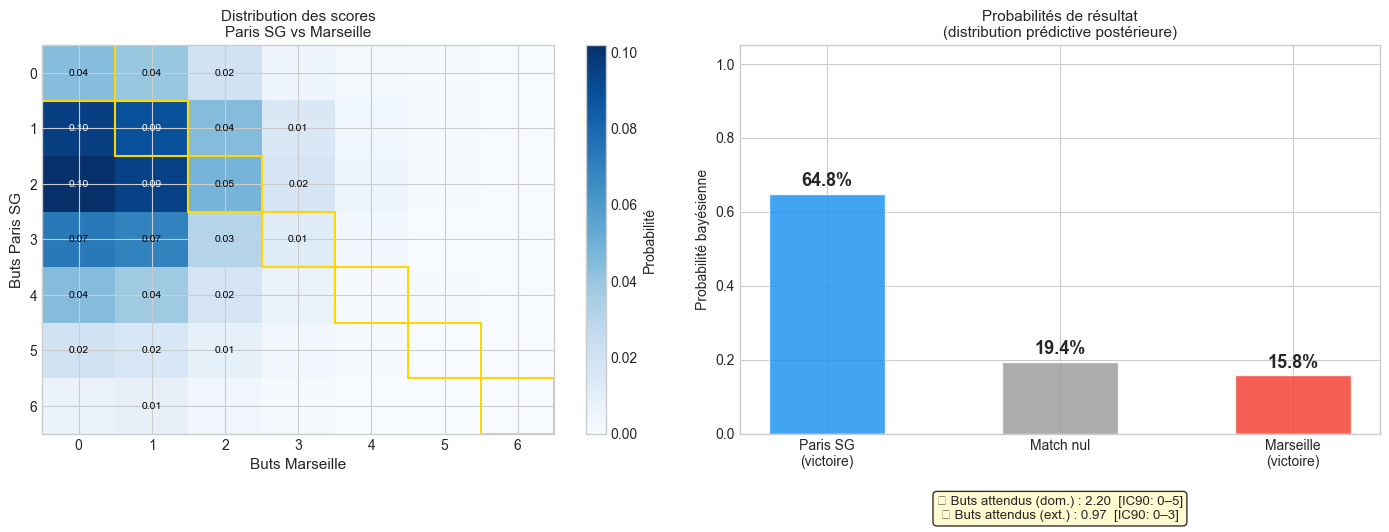

PSG gagne     : 64.8%
Match nul     : 19.4%
Marseille gagne : 15.8%


In [ ]:
# ── Le Classique : PSG vs Marseille 
print("=" * 55)
print("  LE CLASSIQUE : Paris SG vs Marseille")
print("=" * 55)
probs_cl, ints_cl = plot_match_prediction(
    "Paris SG", "Marseille", idata, teams, team_to_idx
)
print(f"PSG gagne     : {probs_cl['home']:.1%}")
print(f"Match nul     : {probs_cl['draw']:.1%}")
print(f"Marseille gagne : {probs_cl['away']:.1%}")

  Lyon vs Monaco


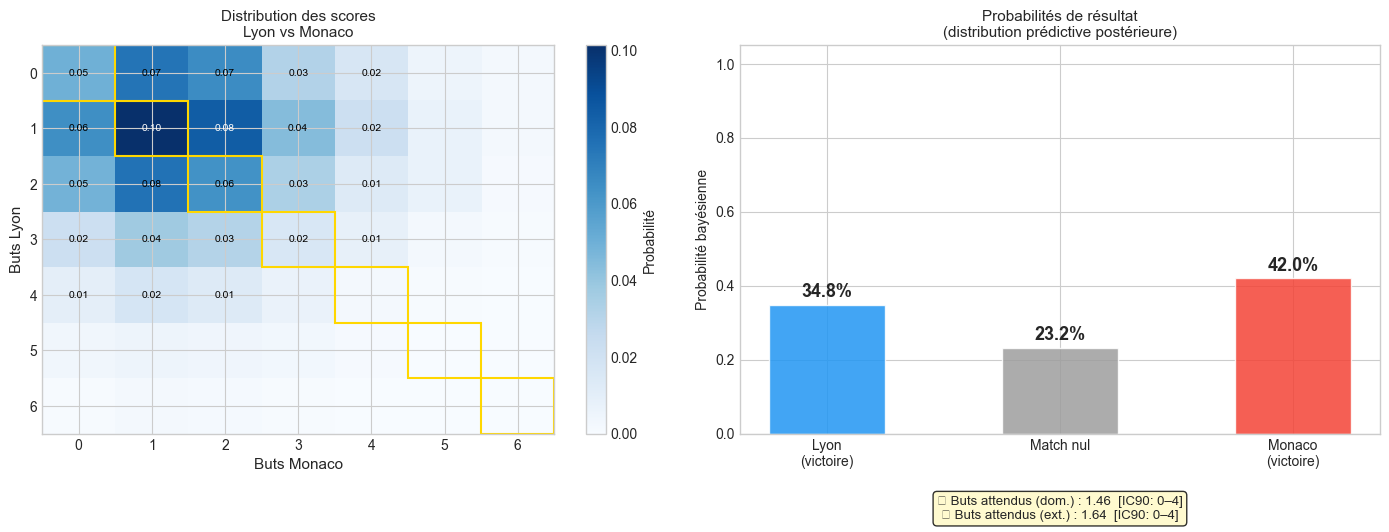

In [ ]:
# ── Derby : Lyon vs Monaco 
print("=" * 55)
print("  Lyon vs Monaco")
print("=" * 55)
probs_lm, ints_lm = plot_match_prediction(
    "Lyon", "Monaco", idata, teams, team_to_idx
)

## 6. Comparaison avec les cotes des bookmakers

### 6.1 Conversion des cotes en probabilités implicites

Un bookmaker propose des cotes décimales $c_H, c_D, c_A$. La probabilité implicite est :
$$p^{\text{bm}}_H = \frac{1/c_H}{1/c_H + 1/c_D + 1/c_A}$$

La **somme** $1/c_H + 1/c_D + 1/c_A > 1$ est la **survaleur** (overround), qui représente la marge du bookmaker.

In [ ]:
# Données avec cotes (saison 2023-24)
df_odds = df[df['Season'] == '2023-24'].copy().reset_index(drop=True)
ODDS_COLS = ['B365H', 'B365D', 'B365A']
df_odds = df_odds.dropna(subset=ODDS_COLS).copy()

# Probabilités implicites brutes
df_odds['raw_pH'] = 1 / df_odds['B365H']
df_odds['raw_pD'] = 1 / df_odds['B365D']
df_odds['raw_pA'] = 1 / df_odds['B365A']
df_odds['overround'] = df_odds['raw_pH'] + df_odds['raw_pD'] + df_odds['raw_pA']

# Normalisation (retrait de la marge)
df_odds['bm_pH'] = df_odds['raw_pH'] / df_odds['overround']
df_odds['bm_pD'] = df_odds['raw_pD'] / df_odds['overround']
df_odds['bm_pA'] = df_odds['raw_pA'] / df_odds['overround']

print(f"📊 Matchs avec cotes Bet365 : {len(df_odds)}")
print(f"💰 Marge bookmaker moyenne  : {(df_odds['overround'] - 1).mean()*100:.2f}%")
print(f"   (Bet365 prélève ≈ {(df_odds['overround'] - 1).mean()*100:.1f}% sur chaque euro misé)\n")
df_odds[['HomeTeam', 'AwayTeam', 'B365H', 'B365D', 'B365A',
         'bm_pH', 'bm_pD', 'bm_pA', 'overround']].head(8)

📊 Matchs avec cotes Bet365 : 306
💰 Marge bookmaker moyenne  : 5.38%
   (Bet365 prélève ≈ 5.4% sur chaque euro misé)



,HomeTeam,AwayTeam,B365H,B365D,B365A,bm_pH,bm_pD,bm_pA,overround
0,Nice,Lille,2.60,3.50,2.70,0.369574,0.274540,0.355886,1.040700
1,Marseille,Reims,1.70,4.00,4.75,0.560886,0.238376,0.200738,1.048762
2,Paris SG,Lorient,1.33,5.50,7.50,0.704646,0.170396,0.124957,1.067031
3,Rennes,Metz,1.40,4.75,7.50,0.675036,0.198958,0.126007,1.058145
4,Strasbourg,Lyon,2.55,3.60,2.55,0.369231,0.261538,0.369231,1.062092
5,Nantes,Toulouse,2.50,3.40,2.75,0.378160,0.278059,0.343782,1.057754
6,Clermont,Monaco,3.60,3.60,2.00,0.263158,0.263158,0.473684,1.055556
7,Brest,Lens,4.00,3.50,1.91,0.236011,0.269726,0.494263,1.059274


### 6.2 Calcul des probabilités du modèle sur tous les matchs

On calcule $P(H), P(D), P(A)$ du modèle pour chaque match observé.  

In [ ]:
# Calcul des probabilités du modèle pour chaque match
model_results = []
total = len(df_odds)

print("Calcul des probabilités du modèle...")
for i, (_, row) in enumerate(df_odds.iterrows()):
    ht, at = row['HomeTeam'], row['AwayTeam']
    if ht not in team_to_idx or at not in team_to_idx:
        model_results.append({'home': np.nan, 'draw': np.nan, 'away': np.nan})
        continue
    _, probs, _ = predict_match(ht, at, idata, teams, team_to_idx, n_samples=3000)
    model_results.append(probs)
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{total} matchs traités...")

df_odds['model_pH'] = [p['home'] for p in model_results]
df_odds['model_pD'] = [p['draw'] for p in model_results]
df_odds['model_pA'] = [p['away'] for p in model_results]

df_odds = df_odds.dropna(subset=['model_pH']).reset_index(drop=True)
print(f"\n✓ {len(df_odds)} matchs analysés")

Calcul des probabilités du modèle...
  50/306 matchs traités...
  100/306 matchs traités...
  150/306 matchs traités...
  200/306 matchs traités...
  250/306 matchs traités...
  300/306 matchs traités...

✓ 306 matchs analysés


## 7. Détection de Value Bets

### Concept fondamental

Un **value bet** existe lorsque le modèle estime qu'un résultat est **sous-évalué** par le bookmaker :

$$\text{Edge} = \frac{p_{\text{modèle}}}{p_{\text{implicite BM}}} > 1$$


**Critère de Kelly** — fraction optimale de la bankroll à miser :
$$f^* = \frac{p_{\text{modèle}} \times (\text{cote} - 1) - (1 - p_{\text{modèle}})}{\text{cote} - 1}$$

In [ ]:
# ── Calcul des value bet 
for outcome, model_col, bm_col, odds_col in [
    ('H', 'model_pH', 'bm_pH', 'B365H'),
    ('D', 'model_pD', 'bm_pD', 'B365D'),
    ('A', 'model_pA', 'bm_pA', 'B365A'),
]:
    p  = df_odds[model_col]
    pi = df_odds[bm_col]
    c  = df_odds[odds_col]
    b  = c - 1              

    df_odds[f'edge_{outcome}'] = p / pi
    df_odds[f'ev_{outcome}']   = p * b - (1 - p)
    df_odds[f'kelly_{outcome}']= ((p * b - (1 - p)) / b).clip(lower=0)

# ── Identification des value bets 
EDGE_THRESHOLD = 1.05   # modèle > 5% au-dessus du bookmaker

records = []
for outcome, result_label, model_col, ev_col, kelly_col, odds_col in [
    ('H', 'Victoire Dom.', 'model_pH', 'ev_H', 'kelly_H', 'B365H'),
    ('D', 'Match Nul',     'model_pD', 'ev_D', 'kelly_D', 'B365D'),
    ('A', 'Victoire Ext.', 'model_pA', 'ev_A', 'kelly_A', 'B365A'),
]:
    edge_col = f'edge_{outcome}'
    mask     = df_odds[edge_col] > EDGE_THRESHOLD
    vb       = df_odds[mask].copy()
    vb['outcome']      = outcome
    vb['result_label'] = result_label
    vb['edge']         = vb[edge_col]
    vb['kelly']        = vb[kelly_col]
    vb['ev']           = vb[ev_col]
    vb['odds']         = vb[odds_col]
    vb['model_p']      = vb[model_col]
    vb['won']          = (vb['FTR'] == outcome)
    records.append(vb[['Date', 'HomeTeam', 'AwayTeam', 'FTR',
                        'result_label', 'outcome', 'odds', 'model_p',
                        'edge', 'kelly','ev', 'won']])

value_bets = pd.concat(records).sort_values('edge', ascending=False).reset_index(drop=True)

print("Top 10 value bets (par edge décroissant) :")
value_bets[['Date', 'HomeTeam', 'AwayTeam', 'result_label',
            'odds', 'model_p', 'edge', 'kelly','ev', 'won']].head(10)

Top 10 value bets (par edge décroissant) :


,Date,HomeTeam,AwayTeam,result_label,odds,model_p,edge,kelly,ev,won
0,2023-12-03,Le Havre,Paris SG,Victoire Dom.,11.00,0.229333,2.650354,0.152267,1.522667,False
1,2023-10-29,Brest,Paris SG,Victoire Dom.,5.75,0.359000,2.184915,0.224053,1.064250,False
2,2023-08-13,Brest,Lens,Victoire Dom.,4.00,0.476333,2.018271,0.301778,0.905333,True
3,2023-08-26,Marseille,Brest,Victoire Ext.,6.00,0.309333,2.010667,0.171200,0.856000,False
4,2024-05-19,Lyon,Strasbourg,Victoire Ext.,7.50,0.251667,1.978260,0.136538,0.887500,False
5,2023-09-02,Brest,Rennes,Victoire Dom.,3.30,0.529333,1.840884,0.324696,0.746800,False
6,2024-05-12,Clermont,Lyon,Victoire Dom.,5.25,0.322333,1.790163,0.162882,0.692250,False
7,2023-11-04,Lorient,Lens,Victoire Dom.,5.00,0.336667,1.769845,0.170833,0.683333,False
8,2023-08-27,Rennes,Le Havre,Victoire Ext.,7.50,0.212667,1.706397,0.091538,0.595000,False
9,2023-11-26,Nice,Toulouse,Victoire Ext.,7.50,0.216000,1.701000,0.095385,0.620000,False


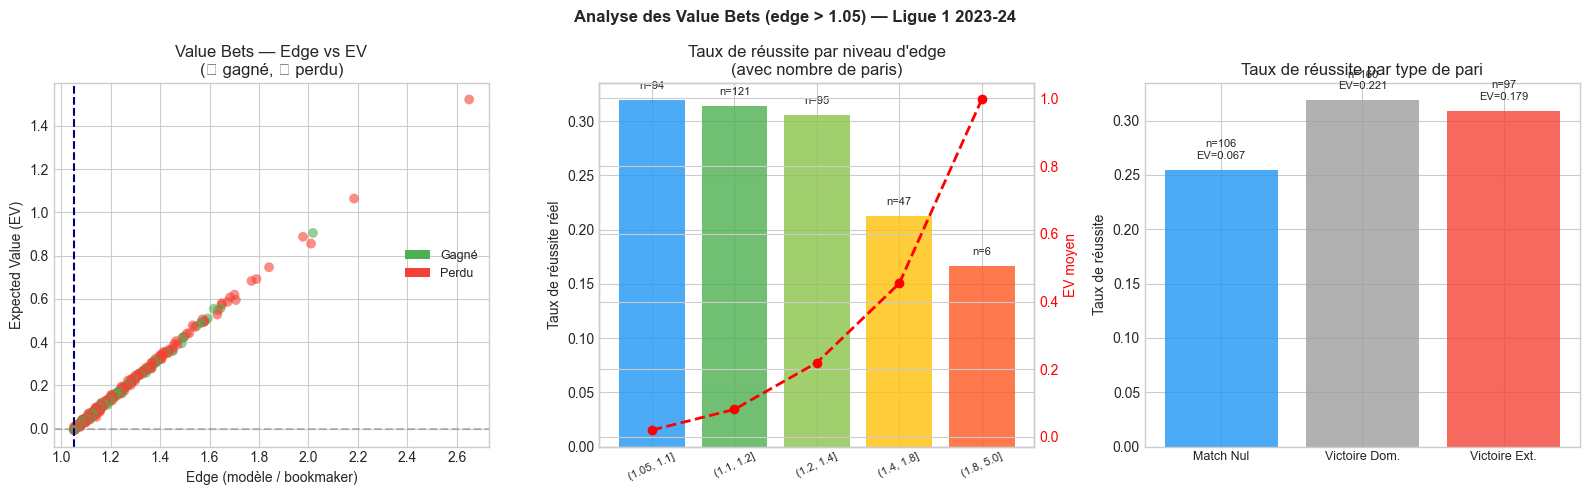

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. Scatter Edge vs EV 
colors_won = value_bets['won'].map({True: '#4CAF50', False: '#F44336'})
sc = axes[0].scatter(value_bets['edge'], value_bets['ev'],
                     c=colors_won, alpha=0.6, s=50, edgecolors='none')
axes[0].axvline(EDGE_THRESHOLD, color='navy', linestyle='--',
                label=f'Seuil = {EDGE_THRESHOLD}')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Edge (modèle / bookmaker)')
axes[0].set_ylabel('Expected Value (EV)')
axes[0].set_title('Value Bets — Edge vs EV\n(🟢 gagné, 🔴 perdu)')
axes[0].legend(fontsize=9)
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#4CAF50', label='Gagné'),
              Patch(facecolor='#F44336', label='Perdu')]
axes[0].legend(handles=legend_els, fontsize=9)

# ── 2. Taux de réussite par catégorie d'edge 
bins_edge = [1.05, 1.10, 1.20, 1.40, 1.80, 5.0]
value_bets['edge_cat'] = pd.cut(value_bets['edge'], bins=bins_edge)
grp = value_bets.groupby('edge_cat', observed=True).agg(
    win_rate=('won', 'mean'),
    count=   ('won', 'count'),
    ev_mean= ('ev',  'mean')
).dropna()

x_pos = np.arange(len(grp))
bars  = axes[1].bar(x_pos, grp['win_rate'], alpha=0.8,
                    color=['#2196F3', '#4CAF50', '#8BC34A', '#FFC107', '#FF5722'])
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([str(c) for c in grp.index], rotation=25, fontsize=8)
axes[1].set_ylabel('Taux de réussite réel')
axes[1].set_title("Taux de réussite par niveau d'edge\n(avec nombre de paris)")
for bar, (_, row) in zip(bars, grp.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'n={int(row["count"])}', ha='center', fontsize=8)

ax_twin = axes[1].twinx()
ax_twin.plot(x_pos, grp['ev_mean'], 'r--o', label='EV moyen', linewidth=2)
ax_twin.set_ylabel('EV moyen', color='red')
ax_twin.tick_params(axis='y', labelcolor='red')

# ── 3. Distribution par type de résultat 
type_stats = value_bets.groupby('result_label').agg(
    count=('won', 'count'),
    win_rate=('won', 'mean'),
    ev_mean=('ev', 'mean')
)
x3 = np.arange(len(type_stats))
axes[2].bar(x3, type_stats['win_rate'], alpha=0.8,
            color=['#2196F3', '#9E9E9E', '#F44336'])
axes[2].set_xticks(x3)
axes[2].set_xticklabels(type_stats.index, fontsize=9)
axes[2].set_ylabel('Taux de réussite')
axes[2].set_title('Taux de réussite par type de pari')
for xi, (label, row) in zip(x3, type_stats.iterrows()):
    axes[2].text(xi, row['win_rate'] + 0.01,
                 f"n={int(row['count'])}\nEV={row['ev_mean']:.3f}",
                 ha='center', fontsize=8)

plt.suptitle(f'Analyse des Value Bets (edge > {EDGE_THRESHOLD}) — Ligue 1 2023-24',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Backtesting — Simulation d'une stratégie de paris

On simule l'évolution de la **bankroll** en pariant sur chaque value bet détecté.

Deux stratégies comparées :
1. **Mise fixe** : 1 unité par pari (simple mais non optimale)
2. **Quart de Kelly** : $f^*/4 \times \text{bankroll}$ (théoriquement optimale en log-espérance, réduite à 25% pour la prudence)

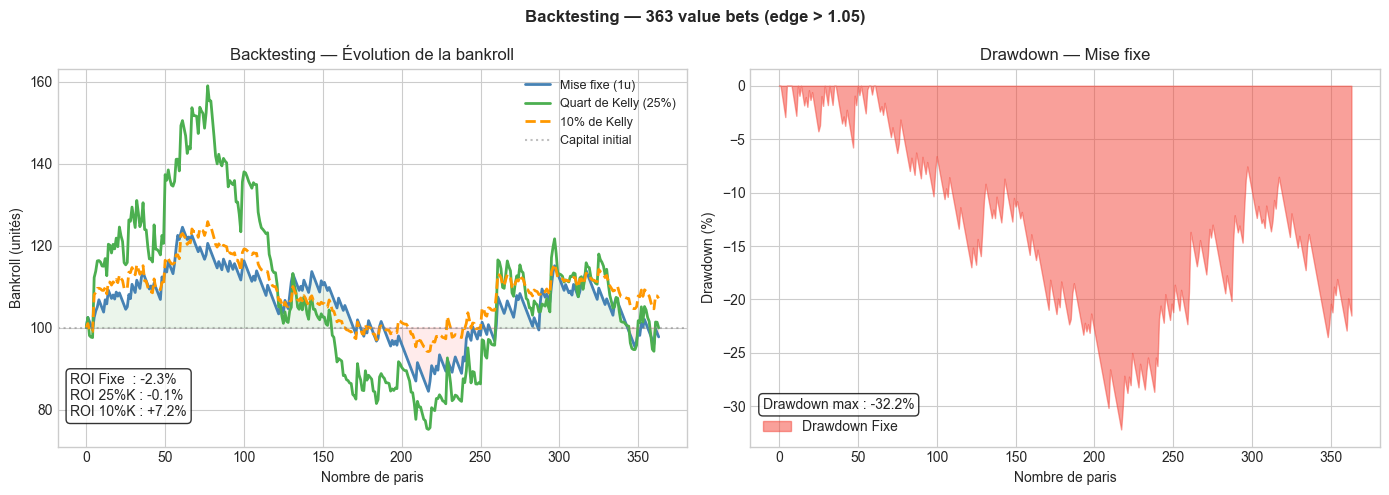


📊 Résultats du backtesting
Nombre de paris    : 363
Taux de réussite   : 29.8%
EV moyen           : 0.1650
ROI Mise fixe      : -2.3%
ROI 25% Kelly      : -0.1%
ROI 10% Kelly      : +7.2%
Drawdown max (fixe): -32.2%


In [ ]:
def simulate_bankroll(vb_df, strategy='fixed', kelly_fraction=0.25,
                      initial_bankroll=100.0, max_stake_pct=0.05):
   
    bankroll = initial_bankroll
    history  = [bankroll]
    stakes   = []

    for _, bet in vb_df.iterrows():
        if bankroll <= 0:
            break

        if strategy == 'fixed':
            stake = 1.0
        else:
            stake = bankroll * bet['kelly'] * kelly_fraction
            stake = min(stake, bankroll * max_stake_pct)
            stake = max(stake, 0.01)   # mise minimale

        if bet['won']:
            gain = stake * (bet['odds'] - 1)
            bankroll += gain
        else:
            bankroll -= stake

        history.append(bankroll)
        stakes.append(stake)

    return np.array(history), np.array(stakes) if stakes else np.array([])


# Trier par date et simuler
vb_sorted = value_bets.sort_values('Date').reset_index(drop=True)

hist_fixed, stakes_fixed   = simulate_bankroll(vb_sorted, 'fixed')
hist_kelly, stakes_kelly   = simulate_bankroll(vb_sorted, 'kelly', kelly_fraction=0.25)
hist_half,  stakes_half    = simulate_bankroll(vb_sorted, 'kelly', kelly_fraction=0.10)

# ── Graphique de l'évolution de la bankroll
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(hist_fixed))
ax.plot(x, hist_fixed, label='Mise fixe (1u)', color='steelblue', linewidth=2)
ax.plot(np.arange(len(hist_kelly)), hist_kelly,
        label='Quart de Kelly (25%)', color='#4CAF50', linewidth=2)
ax.plot(np.arange(len(hist_half)),  hist_half,
        label='10% de Kelly', color='#FF9800', linewidth=2, linestyle='--')
ax.axhline(100, color='gray', linestyle=':', alpha=0.5, label='Capital initial')
ax.fill_between(x, 100, hist_fixed,
                where=hist_fixed >= 100, alpha=0.08, color='green')
ax.fill_between(x, 100, hist_fixed,
                where=hist_fixed  < 100, alpha=0.08, color='red')
ax.set_xlabel('Nombre de paris')
ax.set_ylabel('Bankroll (unités)')
ax.set_title('Backtesting — Évolution de la bankroll')
ax.legend(fontsize=9)

# Stats
roi_fixed = (hist_fixed[-1] - 100) / 100 * 100
roi_kelly = (hist_kelly[-1] - 100) / 100 * 100
roi_half  = (hist_half[-1]  - 100) / 100 * 100
ax.text(0.02, 0.08,
        f"ROI Fixe  : {roi_fixed:+.1f}%\n"
        f"ROI 25%K : {roi_kelly:+.1f}%\n"
        f"ROI 10%K : {roi_half:+.1f}%",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Drawdown
ax2 = axes[1]
drawdown_fixed = (hist_fixed - np.maximum.accumulate(hist_fixed)) / np.maximum.accumulate(hist_fixed) * 100
ax2.fill_between(x, drawdown_fixed, 0, alpha=0.5, color='#F44336', label='Drawdown Fixe')
ax2.set_xlabel('Nombre de paris')
ax2.set_ylabel('Drawdown (%)')
ax2.set_title('Drawdown — Mise fixe')
ax2.legend()
max_dd = drawdown_fixed.min()
ax2.text(0.02, 0.1, f"Drawdown max : {max_dd:.1f}%",
         transform=ax2.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle(f'Backtesting — {len(vb_sorted)} value bets (edge > {EDGE_THRESHOLD})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Résultats du backtesting")
print("=" * 40)
print(f"Nombre de paris    : {len(vb_sorted)}")
print(f"Taux de réussite   : {vb_sorted['won'].mean():.1%}")
print(f"EV moyen           : {vb_sorted['ev'].mean():.4f}")
print(f"ROI Mise fixe      : {roi_fixed:+.1f}%")
print(f"ROI 25% Kelly      : {roi_kelly:+.1f}%")
print(f"ROI 10% Kelly      : {roi_half:+.1f}%")
print(f"Drawdown max (fixe): {max_dd:.1f}%")

## 9. Conclusion et Perspectives


